# **Lab 4.2 NN MLP and CNN**

In [1]:
%pip install --upgrade pip
%pip install torch torchvision opencv-python numpy scikit-image matplotlib tqdm tensorboard

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,Subset
from torch.utils.tensorboard import SummaryWriter
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

Complete the `load_data()` function that loads the image using `ImageFolder()` with the specific `transforms.compose()` provided below.
`load_data()` will return `DataLoader()` and print the information about the Dataset.
This function must load only a pair of classes from the entire dataset.
Please ensure that the final image is in grayscale and has a size of 28x28.

`transforms.Compose()` :
- `transforms.Resize(32)`
- `transforms.ToTensor()`
- `transforms.Pad()`
- `transforms.RandomRotation(45),`
- `transforms.CenterCrop(28)`

Resource : [`transforms.Compose()`](https://pytorch.org/vision/main/generated/torchvision.transforms.Compose.html#compose), [`torchvision.transforms v1`](<https://pytorch.org/vision/stable/transforms.html#v1-api-reference:~:text=custom)%20tv_tensor%20type.-,V1%20API%20Reference,-Geometry>)

In [3]:
def load_data(path, class_names):
    ### START CODE HERE ###
    transform = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),
        transforms.Pad(50, padding_mode="constant", fill=1.0),
        transforms.RandomRotation(45),
        transforms.CenterCrop(28),
        transforms.Grayscale(num_output_channels=1), 
    ])

    dataset = ImageFolder(path, transform=transform)
    
    if class_names:
        class_indices = [dataset.class_to_idx[cls] for cls in class_names if cls in dataset.class_to_idx]
        filtered_indices = [i for i, (_, label) in enumerate(dataset) if label in class_indices]
        dataset = Subset(dataset, filtered_indices)
    
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

    print("📃Train Dataset:")
    for class_name in class_names:
        class_idx = dataset.dataset.class_to_idx[class_name] if hasattr(dataset, 'dataset') else dataset.class_to_idx[class_name]
        train_count = sum(1 for _, label in train_dataset if label == class_idx)
        print(f"\tNumber of images in class {class_name}: {train_count}")
    print(f"\tNumber of training samples: {len(train_dataset)}")
    
    print("\n📃Test Dataset:")
    for class_name in class_names:
        class_idx = dataset.dataset.class_to_idx[class_name] if hasattr(dataset, 'dataset') else dataset.class_to_idx[class_name]
        test_count = sum(1 for _, label in test_dataset if label == class_idx)
        print(f"\tNumber of images in class {class_name}: {test_count}")
    print(f"\tNumber of testing samples: {len(test_dataset)}")

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

    return train_loader, test_loader
    ### END CODE HERE ###

In [4]:
def show_first_batch_image(data_loader):
    images, labels = next(iter(data_loader))
    fig, axs = plt.subplots(4, 4, figsize=(12, 12))
    for i in range(16):
        axs[i // 4, i % 4].imshow(images[i].permute(1, 2, 0))
        axs[i // 4, i % 4].set_title(f"Label: {labels[i].item()}")
        axs[i // 4, i % 4].axis("off")
    plt.tight_layout()
    plt.show()

Use your `load_data()` function to load the dataset in the cell below. Then, display the image from the first batch.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

```
📃Train Dataset:
	Number of images in class 0: 313
	Number of images in class 1: 308
	Number of training samples: 621

📃Test Dataset:
	Number of images in class 0: 75
	Number of images in class 1: 81
	Number of testing samples: 156
```


![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/03.png?raw=true)

</details>

📃Train Dataset:
	Number of images in class 0: 302
	Number of images in class 1: 319
	Number of training samples: 621

📃Test Dataset:
	Number of images in class 0: 86
	Number of images in class 1: 70
	Number of testing samples: 156


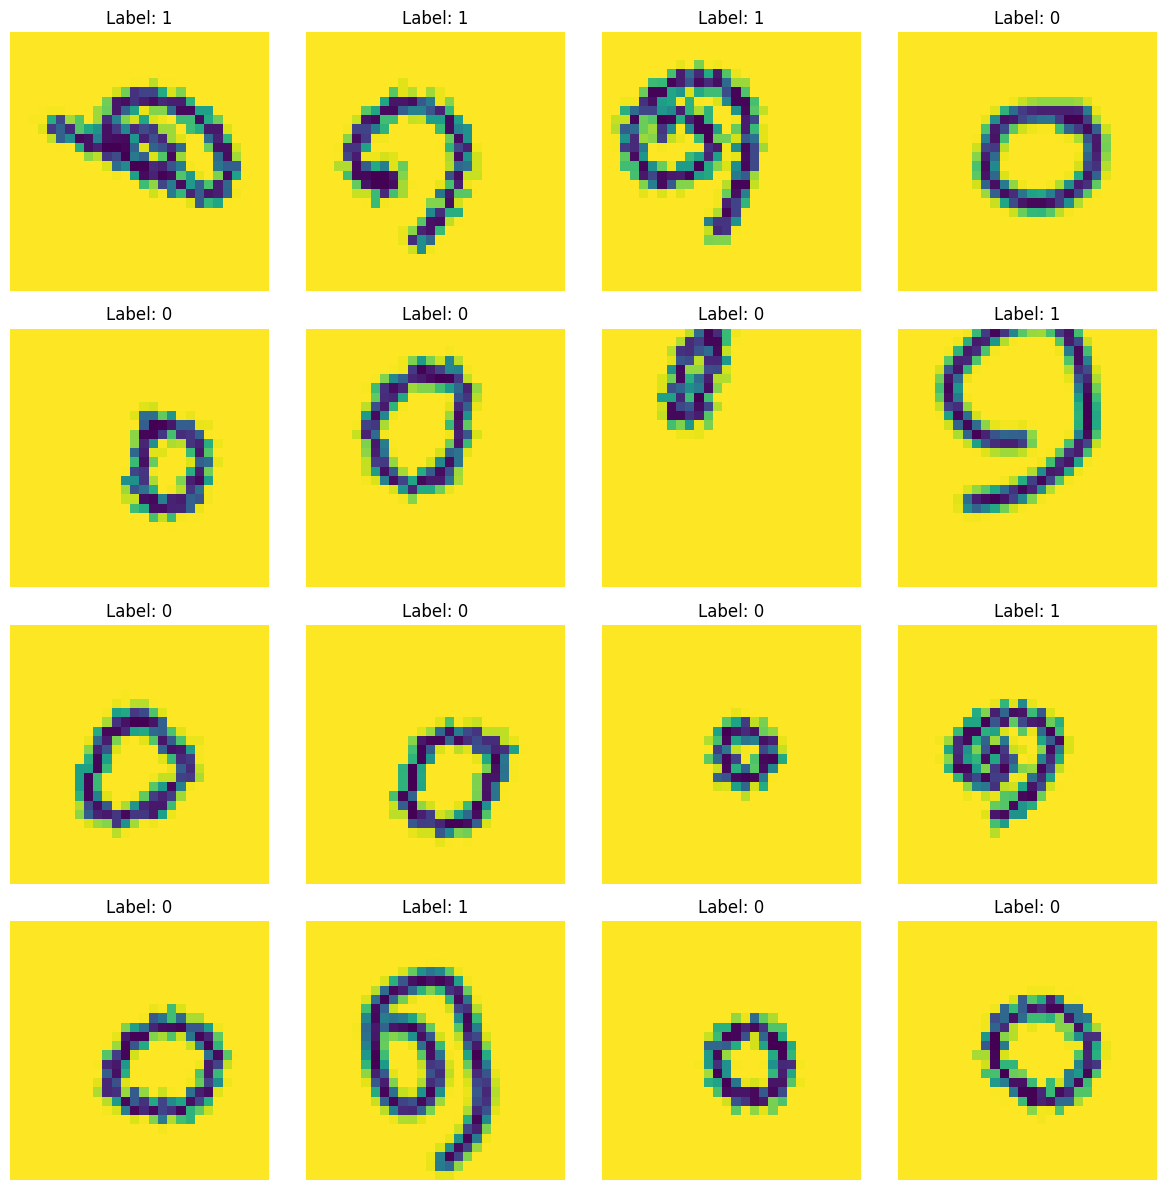

In [5]:
### START CODE HERE ###
class_names = ['0', '1']
train_loader, test_loader = load_data('./thai-handwriting-number.appspot.com',class_names)
show_first_batch_image(train_loader)


### END CODE HERE ###

**Create Models**
1. **NN (Neural Network)**:
- **Input**: 28x28 grayscale images (1 channel)
- **Architecture**: Single fully connected layer with sigmoid activation
- **Output**: Single neuron output with sigmoid activation
- **Description**: This is a simple feedforward neural network with a single fully connected layer. It takes input images, flattens them, passes through a fully connected layer, and applies sigmoid activation to produce the output.

2. **MLP (Multi-Layer Perceptron)**:
- **Input**: 28x28 grayscale images (1 channel)
- **Architecture**: Two fully connected layers with sigmoid activations
- **Output**: Single neuron output with sigmoid activation
- **Description**: This is a multi-layer perceptron with two fully connected layers. After flattening the input images, it passes through the first fully connected layer with sigmoid activation, followed by the second fully connected layer with sigmoid activation, producing the output.

3. **CNN (Convolutional Neural Network)**:
- **Input**: 28x28 grayscale images (1 channel)
- **Architecture**: Two convolutional layers with ReLU activations, followed by two fully connected layers with ReLU activations
- **Output**: Single neuron output with sigmoid activation
- **Description**: This is a convolutional neural network with two convolutional layers followed by two fully connected layers. It applies convolutional operations with ReLU activations, followed by flattening the output and passing through fully connected layers with ReLU activations. Finally, it produces a single neuron output with sigmoid activation.


Every model should have a `get_features()` method that returns the result from all layers.

In [31]:
### START CODE HERE ###
class NN(nn.Module):
    def __init__(self, input_size=28*28, num_classes=1):
        super(NN, self).__init__()
        self.fc1 = nn.Linear(input_size, num_classes)
        
    def get_features(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        x = torch.sigmoid(self.fc1(x))  # Activation function
        return x
        
    def forward(self, x):
        x = self.get_features(x)
        return x
    
class MLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=16):
        super(MLP, self).__init__()
        # Two fully connected layers as described
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)  # Single neuron output
        
    def get_features(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)  # Shape: [batch, 28*28]
        
        # First fully connected layer with sigmoid activation
        x = torch.sigmoid(self.fc1(x))  # Shape: [batch, hidden_size]
        
        return x
        
    def forward(self, x):
        # Get features from first layer
        features = self.get_features(x)
        
        # Second fully connected layer with sigmoid activation
        x = torch.sigmoid(self.fc2(features))  # Shape: [batch, 1]
        
        return x
    
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # 1 channel input (grayscale)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        
        # Fully connected layers
        # Without pooling: 28x28 -> 28x28 -> 28x28
        self.fc1 = nn.Linear(32 * 28 * 28, 128)  # 32 channels, 28x28 size
        self.fc2 = nn.Linear(128, 1)  # Single neuron output
    
    def get_features(self, x):
        # First conv layer + ReLU (no pooling)
        x = torch.relu(self.conv1(x))  # Shape: [batch, 16, 28, 28]
        
        # Second conv layer + ReLU (no pooling)
        x = torch.relu(self.conv2(x))  # Shape: [batch, 32, 28, 28]
        
        # Flatten
        x = x.view(x.size(0), -1)  # Shape: [batch, 32*28*28]
        
        # First fully connected layer + ReLU
        x = torch.relu(self.fc1(x))  # Shape: [batch, 128]
        
        return x
        
    def forward(self, x):
        # Get features from all layers
        features = self.get_features(x)
        
        # Second fully connected layer + sigmoid activation
        x = torch.sigmoid(self.fc2(features))  # Shape: [batch, 1]
        
        return x

Complete the function below. This function will be used to display the feature map from the models at every epoch on TensorBoard.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output that will be display on TensorBoard</b>
</font>
</summary>

- The output should resemble this, but not be identical
- `NN()`<br>
![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/04.png?raw=true)
- `MLP()`<br>
![image-2.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/05.png?raw=true)
- `CNN()`<br>
![image-3.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/06.png?raw=true)
</details>

In [7]:
def show_featuremaps(feats):
    ### START CODE HERE ###
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Convert tensor to numpy if needed
    if hasattr(feats, 'detach'):
        feats = feats.detach().cpu().numpy()
    elif hasattr(feats, 'numpy'):
        feats = feats.numpy()

    # Handle different input shapes
    if len(feats.shape) == 4:  # CNN: (batch, channels, height, width)
        feats = feats[0]  # Take first sample
        n_maps = feats.shape[0]
    elif len(feats.shape) == 2:  # NN/MLP: (batch, features)
        feats = feats[0]  # Take first sample
        # Reshape 1D features into 2D for visualization
        n_features = len(feats)
        grid_size = int(np.ceil(np.sqrt(n_features)))
        padded = np.zeros(grid_size * grid_size)
        padded[:n_features] = feats
        feats = padded.reshape(1, grid_size, grid_size)
        n_maps = 1
    elif len(feats.shape) == 1:  # 1D features (single sample)
        # Reshape 1D features into 2D for visualization
        n_features = len(feats)
        grid_size = int(np.ceil(np.sqrt(n_features)))
        padded = np.zeros(grid_size * grid_size)
        padded[:n_features] = feats
        feats = padded.reshape(1, grid_size, grid_size)
        n_maps = 1
    else:
        n_maps = feats.shape[0] if len(feats.shape) == 3 else 1

    # Create subplot grid
    if n_maps == 1:
        rows, cols = 1, 1
    else:
        cols = min(4, n_maps)
        rows = int(np.ceil(n_maps / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

    # Handle single subplot
    if n_maps == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    # Plot feature maps
    for i in range(n_maps):
        if len(feats.shape) == 3:
            img = feats[i]
        else:
            img = feats.reshape(int(np.sqrt(len(feats))), -1)
    
        axes[i].imshow(img, cmap='viridis')
        axes[i].set_title(f'Feature Map {i+1}')
        axes[i].axis('off')
        # Removed colorbar line: plt.colorbar(im, ax=axes[i])

    # Hide unused subplots
    for i in range(n_maps, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    fig = plt.gcf()

    ### END CODE HERE ###
    return fig

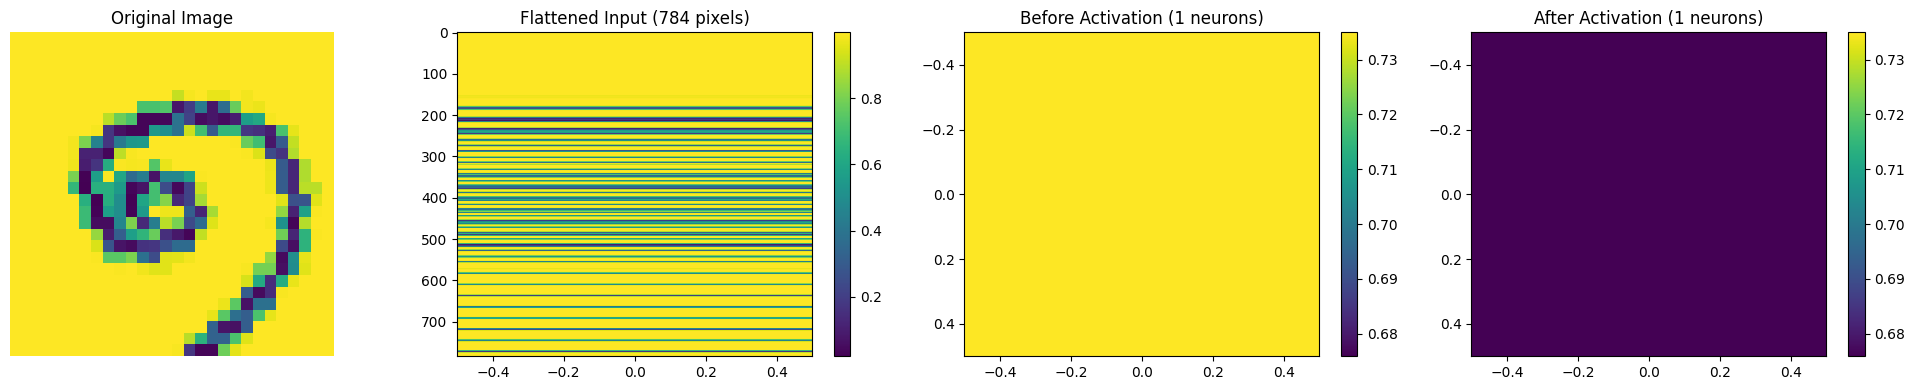

In [ ]:
# Create model and put in eval mode
model = NN()
model.eval()

for images, labels in train_loader:
    with torch.no_grad():
        # Get first image from batch
        img = images[0]
        img = transforms.Grayscale(num_output_channels=1)(img)  # Ensure image has 3 channels
        
        
        plt.figure(figsize=(20, 4))
        
        # 1. Show original image
        plt.subplot(1, 4, 1)
        plt.imshow(img.permute(1, 2, 0))
        plt.title("Original Image")
        plt.axis('off')
        
        # 2. Show flattened input
        flattened = img.view(-1)  # Flatten to 1D
        plt.subplot(1, 4, 2)
        plt.imshow(flattened.reshape(-1, 1), cmap='viridis', aspect='auto')
        plt.title("Flattened Input (784 pixels)")
        plt.colorbar()

        
        # 3. Show linear transformation (before activation)
        x_flat = img.view(1, -1)  # Add batch dimension and flatten
        linear_output = model.fc1(x_flat)  # Before sigmoid

        # Assign linear_output to linear_values for consistent scaling
        activated_output = model.get_features(img)
        linear_values = linear_output.detach().cpu().numpy()
        activated_values = activated_output.detach().cpu().numpy()
        last_output = model.forward(img)

        # Calculate global min/max for consistent color scaling
        vmin = min(linear_values.min(), activated_values.min())
        vmax = max(linear_values.max(), activated_values.max())
        
        plt.subplot(1, 4, 3)
        plt.imshow(linear_values.reshape(-1, 1), cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
        plt.title(f"Before Activation ({linear_output.shape[1]} neurons)")
        plt.colorbar()
        
        # 4. Show after activation
        plt.subplot(1, 4, 4)
        plt.imshow(activated_values.reshape(-1, 1), cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
        plt.title(f"After Activation ({activated_output.shape[1]} neurons)")
        plt.colorbar()
        
        plt.tight_layout()
        plt.show()
    break



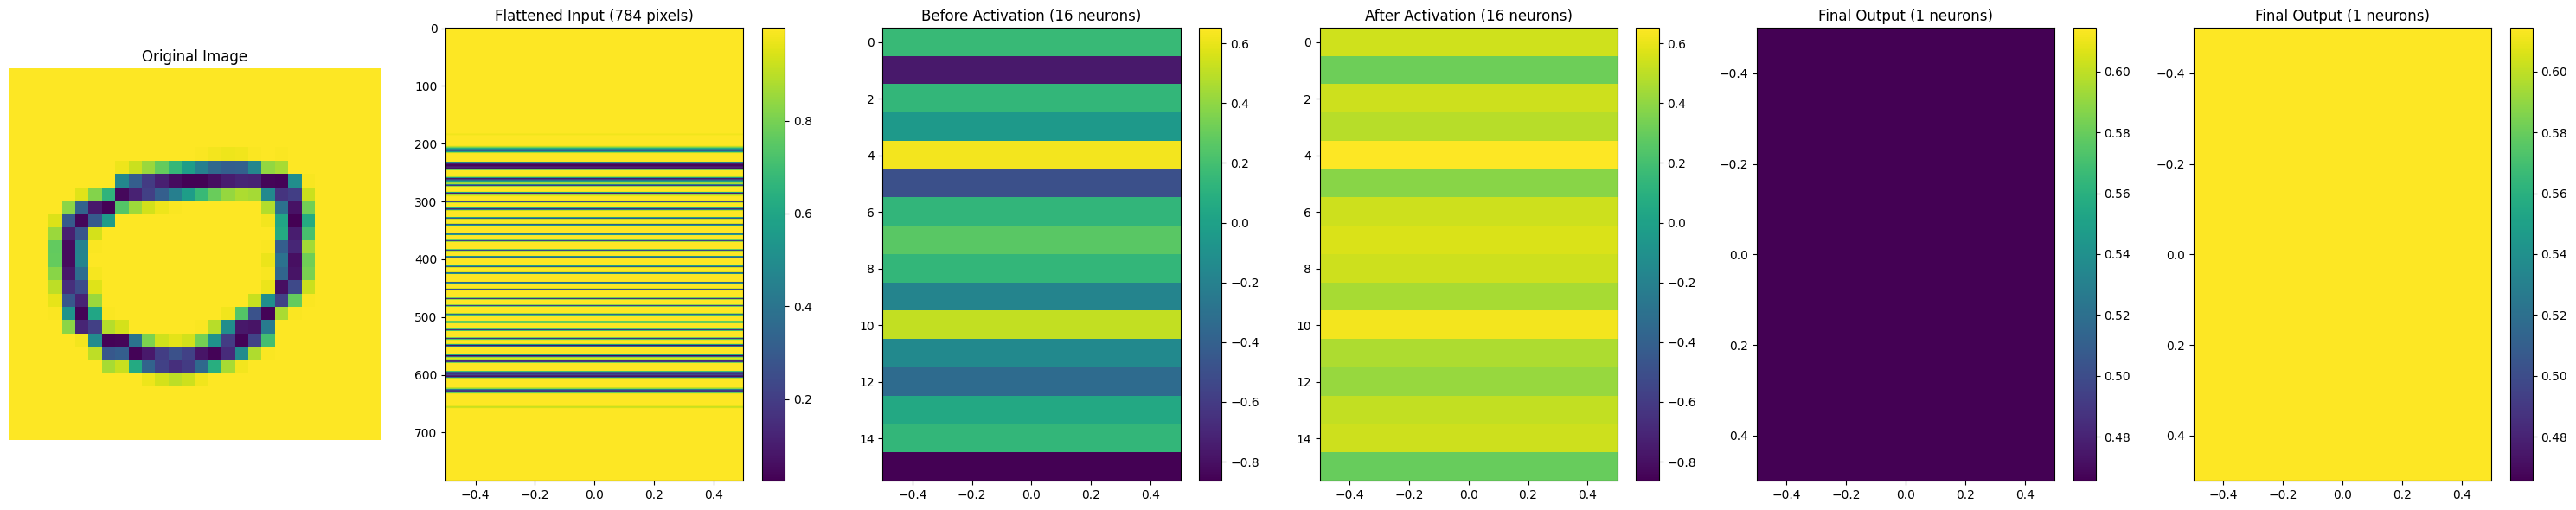

In [9]:
# Create model and put in eval mode
model = MLP()
model.eval()

for images, labels in train_loader:
    with torch.no_grad():
        # Get first image from batch
        img = images[0]
        img = transforms.Grayscale(num_output_channels=1)(img)  
        
        plt.figure(figsize=(30, 6))  # Increase width for 5 subplots
        
        # 1. Show original image
        plt.subplot(1, 6, 1)  # Changed to 1, 5, 1
        plt.imshow(img.permute(1, 2, 0))
        plt.title("Original Image")
        plt.axis('off')
        
        # 2. Show flattened input
        flattened = img.view(-1)  # Flatten to 1D
        plt.subplot(1, 6, 2)  # Changed to 1, 5, 2
        plt.imshow(flattened.reshape(-1, 1), cmap='viridis', aspect='auto')
        plt.title("Flattened Input (784 pixels)")
        plt.colorbar()

        # 3. Show linear transformation (before activation)
        x_flat = img.view(1, -1)  # Add batch dimension and flatten
        linear_output = model.fc1(x_flat)  # Before sigmoid

        linear_values = linear_output.detach().cpu().numpy()
        activated_output = model.get_features(img)
        activated_values = activated_output.detach().cpu().numpy()
        vmin = min(linear_values.min(), activated_values.min())
        vmax = max(linear_values.max(), activated_values.max())
        plt.subplot(1, 6, 3)
        plt.imshow(linear_values.reshape(-1, 1), cmap='viridis', aspect='auto',vmin=vmin, vmax=vmax
                   )
        plt.title(f"Before Activation ({linear_output.shape[1]} neurons)")
        plt.colorbar()
        
        # 4. Show linear transformation (after activation)
        plt.subplot(1, 6, 4)
        plt.imshow(activated_values.reshape(-1, 1), cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax
                   )
        plt.title(f"After Activation ({activated_output.shape[1]} neurons)")
        plt.colorbar()


        # 5. Show final output (before sigmoid)
        last_output = model.fc2(activated_output)  # Final output before sigmoid
        last_values = last_output.detach().cpu().numpy()
        last_output_1 = model.forward(img)
        last_values_1 = last_output_1.detach().cpu().numpy()
        vmin = min(last_values_1.min(), last_values.min())
        vmax = max(last_values_1.max(), last_values.max())
        plt.subplot(1, 6, 5)  # Now correctly 1, 5, 5
        plt.imshow(last_values.reshape(-1, 1), cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax
                   )
        plt.title(f"Final Output ({last_output.shape[1]} neurons)")
        plt.colorbar()

        # 6. Show final output (after sigmoid)
        plt.subplot(1, 6, 6)  # Now correctly 1, 5, 6
        plt.imshow(last_values_1.reshape(-1, 1), cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
        plt.title(f"Final Output ({last_output_1.shape[1]} neurons)")
        plt.colorbar()
        
        plt.tight_layout()
        plt.show()
    break

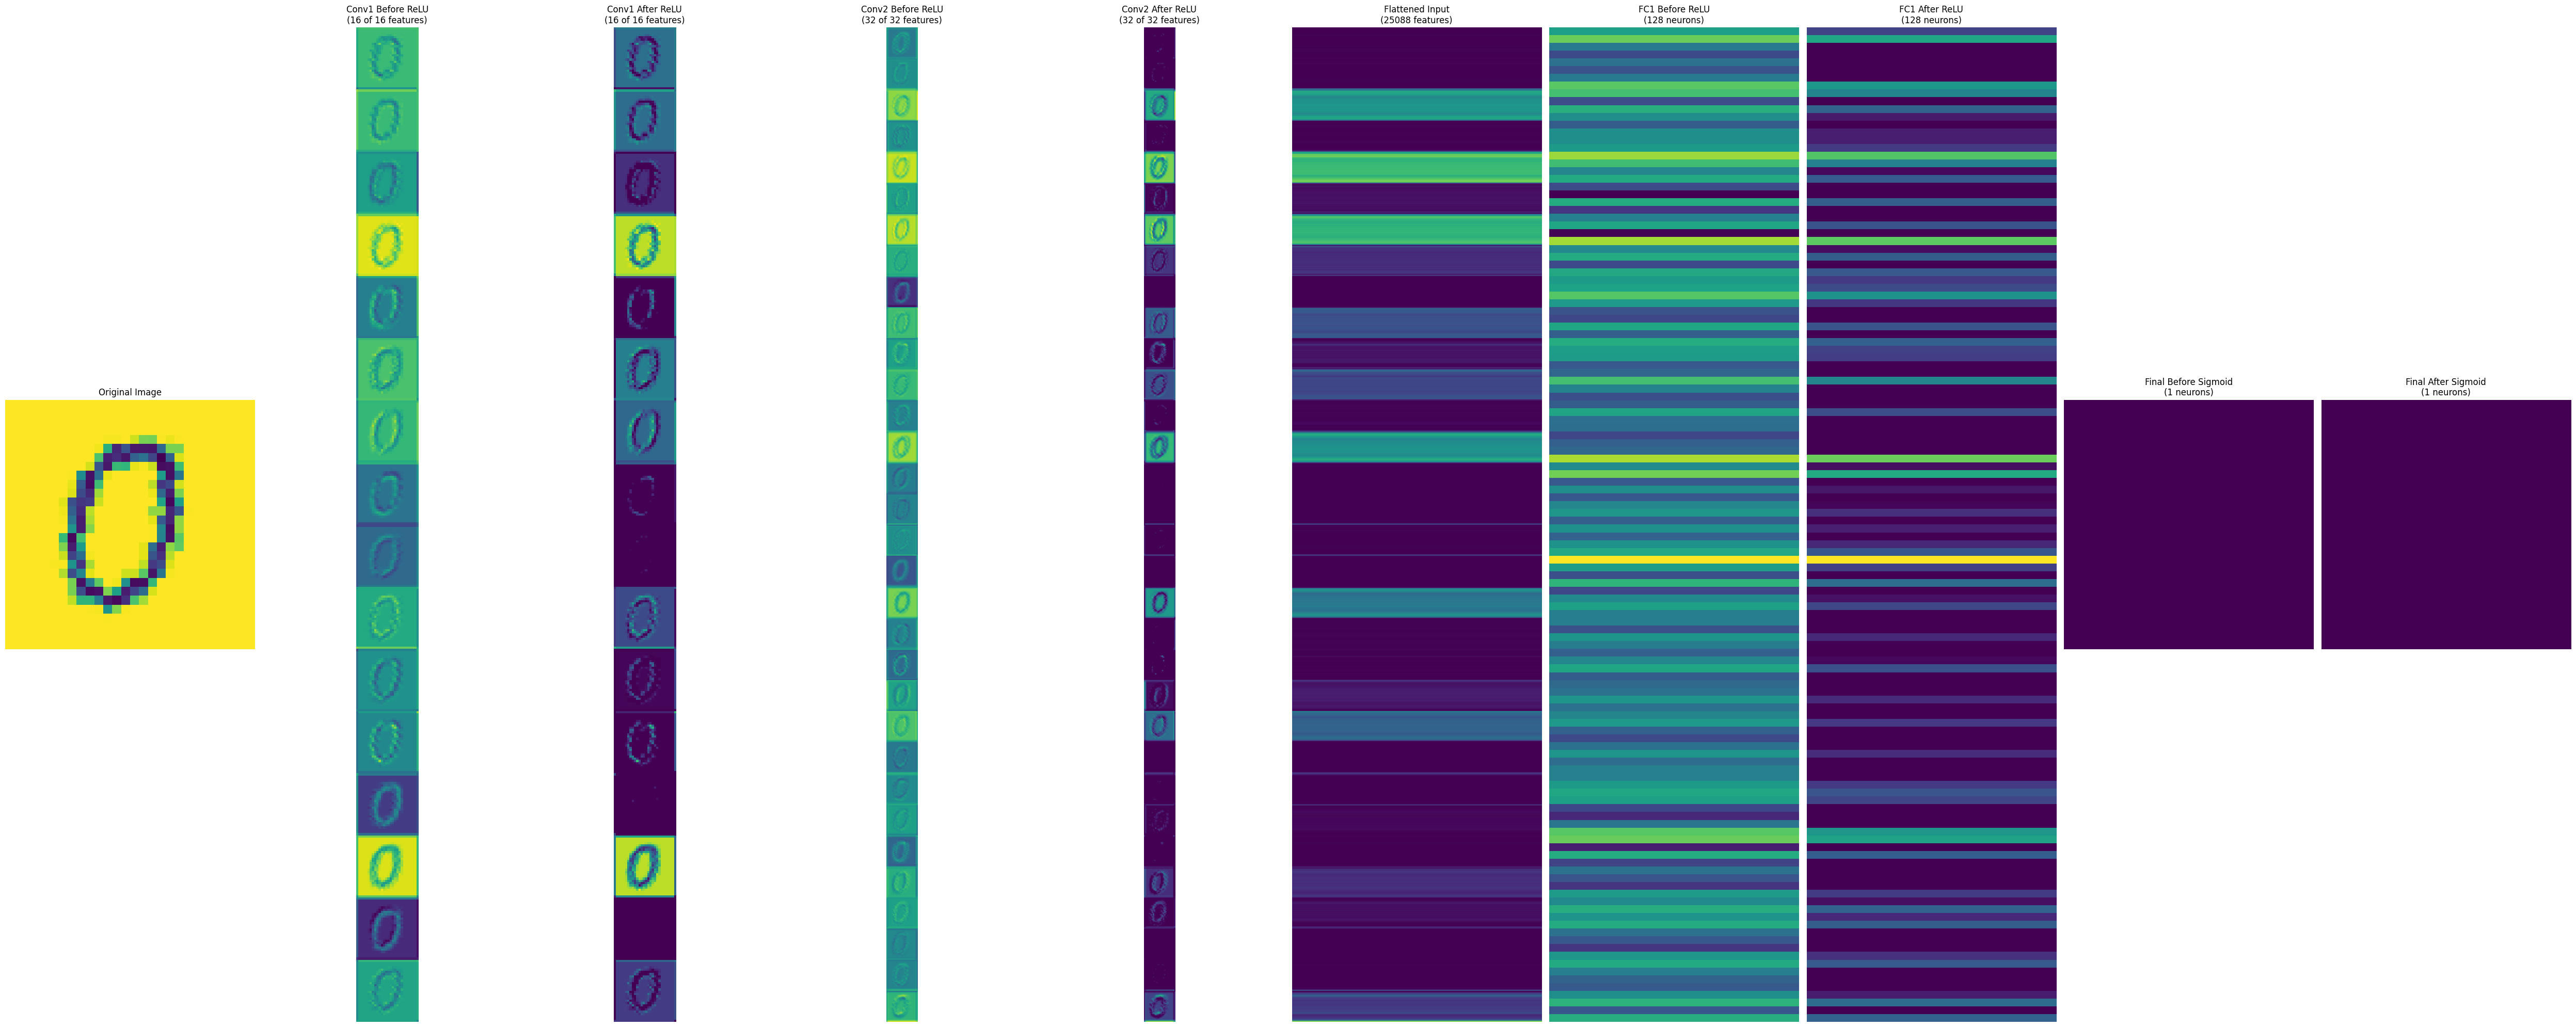

In [36]:
# Create model and put in eval mode
model = CNN()
model.eval()

# Visualization code
for images, labels in train_loader:
    with torch.no_grad():
        # Get first image from batch
        img = images[0]
        img = transforms.Grayscale(num_output_channels=1)(img)  
        
        # Add batch dimension for model input
        img_batch = img.unsqueeze(0)  # Shape: [1, 1, 28, 28]
        
        # Extract conv features manually by accessing model layers
        # First conv layer (before and after ReLU)
        conv1_before = model.conv1(img_batch)
        conv1_after = torch.relu(conv1_before)
        
        # Second conv layer (before and after ReLU) - NO POOLING
        conv2_before = model.conv2(conv1_after)  # Direct from conv1_after
        conv2_after = torch.relu(conv2_before)
        
        # Get flattened features
        flattened = conv2_after.view(conv2_after.size(0), -1)  # Flatten for FC layers
        
        # Get FC1 features (before and after ReLU)
        fc1_before = model.fc1(flattened)  # Linear transformation
        fc1_after = torch.relu(fc1_before)  # After ReLU activation
        
        # Get final output (before and after sigmoid)
        fc2_before = model.fc2(fc1_after)  # Linear transformation
        final_output = torch.sigmoid(fc2_before)  # After sigmoid activation
        
        # Remove batch dimension but keep all feature maps
        conv1_before = conv1_before[0]  # Shape: [16, 28, 28]
        conv1_after = conv1_after[0]   # Shape: [16, 28, 28]
        conv2_before = conv2_before[0] # Shape: [32, 28, 28]
        conv2_after = conv2_after[0]   # Shape: [32, 28, 28]
        flattened = flattened[0]       # Shape: [32*28*28]
        fc1_before = fc1_before[0]     # Shape: [128]
        fc1_after = fc1_after[0]       # Shape: [128]
        fc2_before = fc2_before[0]     # Shape: [1]
        final_output = final_output[0] # Shape: [1]
        
        # Function to create grid of feature maps
        def create_feature_grid(feature_maps, max_features=16):
            """Create a grid of feature maps for display in a single subplot"""
            num_features = min(max_features, len(feature_maps))
            
            # Get dimensions of individual feature maps
            h, w = feature_maps.shape[1], feature_maps.shape[2]
            
            # Create empty grid (single column)
            grid = torch.zeros((num_features * h, w))
            
            # Fill grid with feature maps
            for i in range(num_features):
                grid[i*h:(i+1)*h, :] = feature_maps[i]
            
            return grid.cpu().numpy(), num_features
        
        plt.figure(figsize=(50, 20))  # Increased width for 10 subplots
        
        # 1. Show original image
        plt.subplot(1, 10, 1)
        plt.imshow(img.permute(1, 2, 0), cmap='viridis')
        plt.title("Original Image")
        plt.axis('off')
        
        # 2. Show Conv1 feature maps (before ReLU)
        plt.subplot(1, 10, 2)
        conv1_before_grid, num_conv1_before = create_feature_grid(conv1_before, max_features=16)
        plt.imshow(conv1_before_grid, cmap='viridis')
        plt.title(f"Conv1 Before ReLU\n({num_conv1_before} of {len(conv1_before)} features)")
        plt.axis('off')
        
        # 3. Show Conv1 feature maps (after ReLU)
        plt.subplot(1, 10, 3)
        conv1_after_grid, num_conv1_after = create_feature_grid(conv1_after, max_features=16)
        plt.imshow(conv1_after_grid, cmap='viridis')
        plt.title(f"Conv1 After ReLU\n({num_conv1_after} of {len(conv1_after)} features)")
        plt.axis('off')
        
        # 4. Show Conv2 feature maps (before ReLU)
        plt.subplot(1, 10, 4)
        conv2_before_grid, num_conv2_before = create_feature_grid(conv2_before, max_features=32)
        plt.imshow(conv2_before_grid, cmap='viridis')
        plt.title(f"Conv2 Before ReLU\n({num_conv2_before} of {len(conv2_before)} features)")
        plt.axis('off')
        
        # 5. Show Conv2 feature maps (after ReLU)
        plt.subplot(1, 10, 5)
        conv2_after_grid, num_conv2_after = create_feature_grid(conv2_after, max_features=32)
        plt.imshow(conv2_after_grid, cmap='viridis')
        plt.title(f"Conv2 After ReLU\n({num_conv2_after} of {len(conv2_after)} features)")
        plt.axis('off')
        
        # 6. Show flattened input
        plt.subplot(1, 10, 6)
        plt.imshow(flattened.reshape(-1, 1), cmap='viridis', aspect='auto')
        plt.title(f"Flattened Input\n({len(flattened)} features)")
        plt.axis('off')
        
        # 7. Show FC1 output (before ReLU)
        plt.subplot(1, 10, 7)
        plt.imshow(fc1_before.reshape(-1, 1), cmap='viridis', aspect='auto')
        plt.title(f"FC1 Before ReLU\n({len(fc1_before)} neurons)")
        plt.axis('off')
        
        # 8. Show FC1 output (after ReLU)
        plt.subplot(1, 10, 8)
        plt.imshow(fc1_after.reshape(-1, 1), cmap='viridis', aspect='auto')
        plt.title(f"FC1 After ReLU\n({len(fc1_after)} neurons)")
        plt.axis('off')
        
        # 9. Show final output (before sigmoid)
        plt.subplot(1, 10, 9)
        # Reshape to match original image size for better visualization
        fc2_before_2d = fc2_before.repeat(28, 28).reshape(28, 28)  # Repeat single value to create 28x28
        plt.imshow(fc2_before_2d, cmap='viridis')
        plt.title(f"Final Before Sigmoid\n({fc2_before.numel()} neurons)")
        plt.axis('off')

        # 10. Show final output (after sigmoid)
        plt.subplot(1, 10, 10)
        # Reshape to match original image size for better visualization
        final_output_2d = final_output.repeat(28, 28).reshape(28, 28)  # Repeat single value to create 28x28
        plt.imshow(final_output_2d, cmap='viridis')
        plt.title(f"Final After Sigmoid\n({final_output.numel()} neurons)")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
    break

TensorBoard 101

Complete the `train()` function in the cell below. This function should evaluate the model at every epoch, log the training loss/accuracy, test loss/accuracy, and display the feature map from all layers of the model at every epoch on TensorBoard. Additionally, it should save the model at the last epoch.

Resource : [PyTorch Training loop](<https://pytorch.org/tutorials/beginner/introyt/trainingyt.html#:~:text=%3D0.9)-,The%20Training%20Loop,-Below%2C%20we%20have>), [TensorBoard](https://pytorch.org/docs/stable/tensorboard.html)

<details>
<summary>
<font size="3" color="orange">
<b>Expected output that will be display on TensorBoard</b>
</font>
</summary>

- The output should resemble this, but not be identical

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/07.png?raw=true)

![image-2.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/08.png?raw=true)
</details>

In [ ]:
class NN(nn.Module):
    def __init__(self, input_size=28*28, num_classes=1):
        super(NN, self).__init__()
        self.fc1 = nn.Linear(input_size, num_classes)
        
    def get_features(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        return x  # Return flattened features before final layer
        
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        x = torch.sigmoid(self.fc1(x))  # Apply sigmoid for binary classification
        return x.squeeze()  # Remove last dimension: [batch, 1] -> [batch]
    
class MLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=16):
        super(MLP, self).__init__()
        # Two fully connected layers as described
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)  # Single neuron output
        
    def get_features(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)  # Shape: [batch, 28*28]
        # First fully connected layer with sigmoid activation
        x = torch.sigmoid(self.fc1(x))  # Shape: [batch, hidden_size]
        
        return x
        
    def forward(self, x):
        # Get features from first layer
        features = self.get_features(x)
        # Second fully connected layer with sigmoid activation
        x = torch.sigmoid(self.fc2(features))  # Shape: [batch, 1]
        
        return x.squeeze()  # Remove last dimension: [batch, 1] -> [batch]
    
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # 1 channel input (grayscale)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        
        # Fully connected layers
        # Without pooling: 28x28 -> 28x28 -> 28x28
        self.fc1 = nn.Linear(32 * 28 * 28, 128)  # 32 channels, 28x28 size
        self.fc2 = nn.Linear(128, 1)  # Single neuron output
    
    def get_features(self, x):
        # First conv layer + ReLU (no pooling)
        x = torch.relu(self.conv1(x))  # Shape: [batch, 16, 28, 28]
        
        # Second conv layer + ReLU (no pooling)
        x = torch.relu(self.conv2(x))  # Shape: [batch, 32, 28, 28]
        
        # Flatten
        x = x.view(x.size(0), -1)  # Shape: [batch, 32*28*28]
        
        # First fully connected layer + ReLU
        x = torch.relu(self.fc1(x))  # Shape: [batch, 128]
        
        return x
        
    def forward(self, x):
        # Get features from all layers
        features = self.get_features(x)
        
        # Second fully connected layer + sigmoid activation
        x = torch.sigmoid(self.fc2(features))  # Shape: [batch, 1]
        
        return x.squeeze()  # Remove last dimension: [batch, 1] -> [batch]
    
def create_cnn_visualization(model, img, device):
    """Create 10-panel visualization for CNN model"""
    import matplotlib.pyplot as plt
    import torch
    from torchvision import transforms
    
    with torch.no_grad():
        # Ensure image is on CPU for visualization
        img_cpu = img.cpu()
        
        # Convert to grayscale for processing
        img_gray = transforms.Grayscale(num_output_channels=1)(img_cpu)
        
        fig, axes = plt.subplots(1, 10, figsize=(50, 20))
        
        # Add batch dimension for model input
        img_batch = img.unsqueeze(0).to(device)  # Shape: [1, 1, 28, 28]
        
        # Extract conv features manually by accessing model layers
        # First conv layer (before and after ReLU)
        conv1_before = model.conv1(img_batch)
        conv1_after = torch.relu(conv1_before)
        
        # Second conv layer (before and after ReLU) - NO POOLING
        conv2_before = model.conv2(conv1_after)  # Direct from conv1_after
        conv2_after = torch.relu(conv2_before)
        
        # Get flattened features
        flattened = conv2_after.view(conv2_after.size(0), -1)  # Flatten for FC layers
        
        # Get FC1 features (before and after ReLU)
        fc1_before = model.fc1(flattened)  # Linear transformation
        fc1_after = torch.relu(fc1_before)  # After ReLU activation
        
        # Get final output (before and after sigmoid)
        fc2_before = model.fc2(fc1_after)  # Linear transformation
        final_output = torch.sigmoid(fc2_before)  # After sigmoid activation
        
        # Remove batch dimension but keep all feature maps
        conv1_before = conv1_before[0]  # Shape: [16, 28, 28]
        conv1_after = conv1_after[0]   # Shape: [16, 28, 28]
        conv2_before = conv2_before[0] # Shape: [32, 28, 28]
        conv2_after = conv2_after[0]   # Shape: [32, 28, 28]
        flattened = flattened[0]       # Shape: [32*28*28]
        fc1_before = fc1_before[0]     # Shape: [128]
        fc1_after = fc1_after[0]       # Shape: [128]
        fc2_before = fc2_before[0]     # Shape: [1]
        final_output = final_output[0] # Shape: [1]
        
        # Function to create grid of feature maps
        def create_feature_grid(feature_maps, max_features=16):
            """Create a grid of feature maps for display in a single subplot"""
            num_features = min(max_features, len(feature_maps))
            
            # Get dimensions of individual feature maps
            h, w = feature_maps.shape[1], feature_maps.shape[2]
            
            # Create empty grid (single column)
            grid = torch.zeros((num_features * h, w))
            
            # Fill grid with feature maps
            for i in range(num_features):
                grid[i*h:(i+1)*h, :] = feature_maps[i]
            
            return grid.cpu().numpy(), num_features
        
        # 1. Show original image
        if img_cpu.shape[0] == 3:  # RGB image
            img_2d = img_gray.squeeze()  # Remove channel dimension
        else:  # Already grayscale
            img_2d = img_cpu.squeeze()
            
        axes[0].imshow(img_2d, cmap='viridis')
        axes[0].set_title("Original Image")
        axes[0].axis('off')
        
        # 2. Show Conv1 feature maps (before ReLU)
        conv1_before_grid, num_conv1_before = create_feature_grid(conv1_before, max_features=16)
        axes[1].imshow(conv1_before_grid, cmap='viridis')
        axes[1].set_title(f"Conv1 Before ReLU\n({num_conv1_before} of {len(conv1_before)} features)")
        axes[1].axis('off')
        
        # 3. Show Conv1 feature maps (after ReLU)
        conv1_after_grid, num_conv1_after = create_feature_grid(conv1_after, max_features=16)
        axes[2].imshow(conv1_after_grid, cmap='viridis')
        axes[2].set_title(f"Conv1 After ReLU\n({num_conv1_after} of {len(conv1_after)} features)")
        axes[2].axis('off')
        
        # 4. Show Conv2 feature maps (before ReLU)
        conv2_before_grid, num_conv2_before = create_feature_grid(conv2_before, max_features=32)
        axes[3].imshow(conv2_before_grid, cmap='viridis')
        axes[3].set_title(f"Conv2 Before ReLU\n({num_conv2_before} of {len(conv2_before)} features)")
        axes[3].axis('off')
        
        # 5. Show Conv2 feature maps (after ReLU)
        conv2_after_grid, num_conv2_after = create_feature_grid(conv2_after, max_features=32)
        axes[4].imshow(conv2_after_grid, cmap='viridis')
        axes[4].set_title(f"Conv2 After ReLU\n({num_conv2_after} of {len(conv2_after)} features)")
        axes[4].axis('off')
        
        # 6. Show flattened input
        axes[5].imshow(flattened.reshape(-1, 1), cmap='viridis', aspect='auto')
        axes[5].set_title(f"Flattened Input\n({len(flattened)} features)")
        axes[5].axis('off')
        
        # 7. Show FC1 output (before ReLU)
        axes[6].imshow(fc1_before.reshape(-1, 1), cmap='viridis', aspect='auto')
        axes[6].set_title(f"FC1 Before ReLU\n({len(fc1_before)} neurons)")
        axes[6].axis('off')
        
        # 8. Show FC1 output (after ReLU)
        axes[7].imshow(fc1_after.reshape(-1, 1), cmap='viridis', aspect='auto')
        axes[7].set_title(f"FC1 After ReLU\n({len(fc1_after)} neurons)")
        axes[7].axis('off')
        
        # 9. Show final output (before sigmoid)
        # Reshape to match original image size for better visualization
        fc2_before_2d = fc2_before.repeat(28, 28).reshape(28, 28)  # Repeat single value to create 28x28
        axes[8].imshow(fc2_before_2d, cmap='viridis')
        axes[8].set_title(f"Final Before Sigmoid\n({fc2_before.numel()} neurons)")
        axes[8].axis('off')

        # 10. Show final output (after sigmoid)
        # Reshape to match original image size for better visualization
        final_output_2d = final_output.repeat(28, 28).reshape(28, 28)  # Repeat single value to create 28x28
        axes[9].imshow(final_output_2d, cmap='viridis')
        axes[9].set_title(f"Final After Sigmoid\n({final_output.numel()} neurons)")
        axes[9].axis('off')
    
    return fig

def create_mlp_visualization(model, img, device):
    """Create 6-panel visualization for MLP model"""
    import matplotlib.pyplot as plt
    import torch
    from torchvision import transforms
    
    with torch.no_grad():
        # Ensure image is on CPU for visualization
        img_cpu = img.cpu()
        
        # Convert to grayscale for processing
        img_gray = transforms.Grayscale(num_output_channels=1)(img_cpu)
        
        fig, axes = plt.subplots(1, 6, figsize=(30, 6))
        
        # 1. Show original image
        if img_cpu.shape[0] == 3:  # RGB image
            img_2d = img_gray.squeeze()  # Remove channel dimension
        else:  # Already grayscale
            img_2d = img_cpu.squeeze()
            
        axes[0].imshow(img_2d, cmap='viridis')
        axes[0].set_title("Original Image")
        axes[0].axis('off')
        
        # 2. Show flattened input
        flattened = img_gray.view(-1)  # Flatten to 1D
        axes[1].imshow(flattened.reshape(-1, 1), cmap='viridis', aspect='auto')
        axes[1].set_title("Flattened Input (784 pixels)")
        axes[1].axis('off')
        
        # Move image to device for model processing
        img_batch = img.unsqueeze(0).to(device)  # Add batch dimension
        
        # 3. Show linear transformation (before activation)
        x_flat = img_batch.view(1, -1)  # Add batch dimension and flatten
        linear_output = model.fc1(x_flat)  # Before sigmoid
        
        # 4. Show linear transformation (after activation)
        activated_output = model.get_features(img_batch)
        
        linear_values = linear_output.detach().cpu().numpy()
        activated_values = activated_output.detach().cpu().numpy()
        
        # Calculate global min/max for consistent color scaling
        vmin = min(linear_values.min(), activated_values.min())
        vmax = max(linear_values.max(), activated_values.max())
        
        axes[2].imshow(linear_values.reshape(-1, 1), cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
        axes[2].set_title(f"Before Activation ({linear_output.size(1)} neurons)")
        axes[2].axis('off')
        
        axes[3].imshow(activated_values.reshape(-1, 1), cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
        axes[3].set_title(f"After Activation ({activated_output.size(1)} neurons)")
        axes[3].axis('off')
        
        # 5. Show final output (before sigmoid)
        last_output = model.fc2(activated_output)  # Final output before sigmoid
        last_values = last_output.detach().cpu().numpy()
        
        # 6. Show final output (after sigmoid)
        last_output_1 = model.forward(img_batch)
        last_values_1 = last_output_1.detach().cpu().numpy()
        
        # Handle scalar outputs by ensuring they're at least 1D
        if last_values.ndim == 0:  # Scalar
            last_values = last_values.reshape(1)
        if last_values_1.ndim == 0:  # Scalar
            last_values_1 = last_values_1.reshape(1)
            
        # Calculate vmin/vmax for final outputs
        vmin_final = min(last_values_1.min(), last_values.min())
        vmax_final = max(last_values_1.max(), last_values.max())
        
        axes[4].imshow(last_values.reshape(-1, 1), cmap='viridis', aspect='auto', vmin=vmin_final, vmax=vmax_final)
        axes[4].set_title(f"Final Output Before Sigmoid ({last_output.numel()} neurons)")
        axes[4].axis('off')
        
        axes[5].imshow(last_values_1.reshape(-1, 1), cmap='viridis', aspect='auto', vmin=vmin_final, vmax=vmax_final)
        axes[5].set_title(f"Final Output After Sigmoid ({last_output_1.numel()} neurons)")
        axes[5].axis('off')
    
    return fig


def create_nn_visualization(model, img, device):
    """Create 4-panel visualization for NN model"""
    import matplotlib.pyplot as plt
    import torch
    from torchvision import transforms
    
    with torch.no_grad():
        # Ensure image is on CPU for visualization
        img_cpu = img.cpu()
    
        # Convert to grayscale for processing but keep original for display
        img_gray = transforms.Grayscale(num_output_channels=1)(img_cpu)
    
        fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    
        # 1. Show original image with viridis colormap
        if img_cpu.shape[0] == 3:  # RGB image
            # Convert to grayscale and squeeze to 2D for viridis colormap
            img_2d = img_gray.squeeze()  # Remove channel dimension
        else:  # Already grayscale
            img_2d = img_cpu.squeeze()
            
        axes[0].imshow(img_2d)
        axes[0].set_title("Original Image")
        axes[0].axis('off')
    
        # 2. Show flattened input
        flattened = img_gray.view(-1)  # Use grayscale version
        axes[1].imshow(flattened.reshape(-1, 1), aspect='auto')
        axes[1].set_title("Flattened Input (784 pixels)")
        axes[1].axis('off')
        
        img_batch = img.unsqueeze(0).to(device)  # Add batch dimension
        
        # Get linear output (before activation)
        x_flat = img_batch.view(1, -1)  # Flatten
        linear_output = model.fc1(x_flat)  # Before sigmoid
        
        # Get final output (after activation)
        final_output = torch.sigmoid(linear_output)
        
        linear_values = linear_output.detach().cpu().numpy()
        final_values = final_output.detach().cpu().numpy()
        
        # Calculate global min/max for consistent color scaling
        vmin = min(linear_values.min(), final_values.min())
        vmax = max(linear_values.max(), final_values.max())
        
        # 3. Before activation
        axes[2].imshow(linear_values.reshape(-1, 1), vmin=vmin, vmax=vmax)
        axes[2].set_title(f"Before Activation ({linear_output.size(1)} neurons)")
        axes[2].axis('off')
        
        # 4. After activation  
        axes[3].imshow(final_values.reshape(-1, 1), vmin=vmin, vmax=vmax)
        axes[3].set_title(f"After Activation ({final_output.size(1)} neurons)")
        axes[3].axis('off')
    
    return fig


def show_featuremaps(model, img, device):
    try:
        if isinstance(model, MLP):
            fig = create_mlp_visualization(model, img, device)
            print("MLP visualization created successfully.")
        elif isinstance(model, CNN):
            fig = create_cnn_visualization(model, img, device)
            print("CNN visualization created successfully.")
        else:
            fig = create_nn_visualization(model, img, device)
            print("NN visualization created successfully.")
    except Exception as e:
        print(f"Error creating visualization: {e}")
    return fig

    

def train(model, train_loader, test_loader, criterion, optimizer, num_epochs, device, model_name):
    from torch.utils.tensorboard import SummaryWriter
    import matplotlib.pyplot as plt
    
    # Create TensorBoard writer
    writer = SummaryWriter(f'runs/{model_name}')
    
    # Move model to device
    model = model.to(device)
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device).float()
            
            optimizer.zero_grad()
            
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            predicted = (output > 0.5).float()
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()
        
        # Calculate training metrics
        train_loss /= len(train_loader)
        train_accuracy = 100. * train_correct / train_total
        
        # Evaluation phase
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device).float()
                
                output = model(data)
                test_loss += criterion(output, target).item()
                
                predicted = (output > 0.5).float()
                test_total += target.size(0)
                test_correct += (predicted == target).sum().item()
                
                # Log feature maps from first test batch only
                if test_total == target.size(0):
                    # Get first image from batch
                    first_img = data[0]
                    
                    # Create the 4-panel visualization for NN
                    try:
                        fig = show_featuremaps(model, first_img, device)
                        writer.add_figure(f'{model_name}/feature_visualization', fig, epoch)
                        plt.close(fig)
                    except Exception as e:
                        print(f"Error creating visualization: {e}")
        
        # Calculate test metrics
        test_loss /= len(test_loader)
        test_accuracy = 100. * test_correct / test_total
        
        # Log metrics to TensorBoard
        writer.add_scalar('Loss/Train', train_loss, epoch)
        writer.add_scalar('Accuracy/Train', train_accuracy, epoch)
        writer.add_scalar('Loss/Test', test_loss, epoch)
        writer.add_scalar('Accuracy/Test', test_accuracy, epoch)
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.2f}%')
    
    # Save model at last epoch
    torch.save(model.state_dict(), f'{model_name}_final.pth')
    
    # Close writer
    writer.close()
    
    print(f'Training completed! Model saved as {model_name}_final.pth')

Use your `train()` function to train all types of models with all combinations of numbers that you've obtained.

In [ ]:
# Fixed training call with proper label mapping
### START CODE HERE ###

# Create device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class_names = ['2', '9']
train_loader_2_9, test_loader_2_9 = load_data('./thai-handwriting-number.appspot.com',class_names)

# Create model
model = NN()

# Create optimizer with the model parameters
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Use BCELoss for binary classification
criterion = nn.BCELoss()

import shutil

# Create a modified train function that handles label mapping
def train_with_label_mapping(model, train_loader, test_loader, criterion, optimizer, num_epochs, device, model_name):
    from torch.utils.tensorboard import SummaryWriter
    import matplotlib.pyplot as plt
    
    # Remove a specific folder and all its contents
    shutil.rmtree(f'runs/{model_name}', ignore_errors=True)

    # Create TensorBoard writer
    writer = SummaryWriter(f'runs/{model_name}')
    
    # Move model to device
    model = model.to(device)
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            # Map labels to binary (0, 1) format
            # The first class becomes 0, second class becomes 1
            unique_labels = torch.unique(target)
            if len(unique_labels) == 2:
                target = (target == unique_labels[1]).float()
            else:
                target = target.float()
            
            optimizer.zero_grad()
            
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            predicted = (output > 0.5).float()
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()
        
        # Calculate training metrics
        train_loss /= len(train_loader)
        train_accuracy = 100. * train_correct / train_total
        
        # Evaluation phase
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                
                # Map labels to binary (0, 1) format
                unique_labels = torch.unique(target)
                if len(unique_labels) == 2:
                    target = (target == unique_labels[1]).float()
                else:
                    target = target.float()
                
                output = model(data)
                test_loss += criterion(output, target).item()
                
                predicted = (output > 0.5).float()
                test_total += target.size(0)
                test_correct += (predicted == target).sum().item()
                
                # Log feature maps from first test batch only
                if test_total == target.size(0):
                    # Get first image from batch
                    first_img = data[0]
                    
                    # Create the 4-panel visualization for NN
                    try:
                        fig = show_featuremaps(model, first_img, device)
                        writer.add_figure(f'{model_name}/feature_visualization', fig, epoch)
                        plt.close(fig)
                    except Exception as e:
                        print(f"Error creating visualization: {e}")
        
        # Calculate test metrics
        test_loss /= len(test_loader)
        test_accuracy = 100. * test_correct / test_total
        
        # Log metrics to TensorBoard
        writer.add_scalar('Loss/Train', train_loss, epoch)
        writer.add_scalar('Accuracy/Train', train_accuracy, epoch)
        writer.add_scalar('Loss/Test', test_loss, epoch)
        writer.add_scalar('Accuracy/Test', test_accuracy, epoch)
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.2f}%')
    
    # Save model at last epoch
    torch.save(model.state_dict(), f'{model_name}_final.pth')
    
    # Close writer
    writer.close()
    
    print(f'Training completed! Model saved as {model_name}_final.pth')

# Train the model with proper label mapping
train_with_label_mapping(model, train_loader_2_9, test_loader_2_9, 
                        criterion=criterion, 
                        optimizer=optimizer, 
                        num_epochs=5, 
                        device=device, 
                        model_name='2_9/NN')

### END CODE HERE ###

Using device: cpu
📃Train Dataset:
	Number of images in class 2: 308
	Number of images in class 9: 313
	Number of training samples: 621

📃Test Dataset:
	Number of images in class 2: 81
	Number of images in class 9: 75
	Number of testing samples: 156
NN visualization created successfully.
Epoch [1/5], Train Loss: 0.7161, Train Acc: 47.67%, Test Loss: 0.7735, Test Acc: 48.08%
NN visualization created successfully.
Epoch [2/5], Train Loss: 0.6862, Train Acc: 55.72%, Test Loss: 0.6710, Test Acc: 50.64%
NN visualization created successfully.
Epoch [3/5], Train Loss: 0.6304, Train Acc: 66.83%, Test Loss: 0.6209, Test Acc: 71.15%
NN visualization created successfully.
Epoch [4/5], Train Loss: 0.6313, Train Acc: 65.06%, Test Loss: 0.5897, Test Acc: 71.15%
NN visualization created successfully.
Epoch [5/5], Train Loss: 0.6085, Train Acc: 65.38%, Test Loss: 0.5730, Test Acc: 78.21%
Training completed! Model saved as 2_9/NN_final.pth


In [47]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create model
model = MLP()

# Create optimizer with the model parameters
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Use BCELoss for binary classification
criterion = nn.BCELoss()

# Train the model
train(model, train_loader, test_loader, 
      criterion=criterion, 
      optimizer=optimizer, 
      num_epochs=1, 
      device=device, 
      model_name='0_1/MLP')

Using device: cpu
MLP visualization created successfully.
Epoch [1/1], Train Loss: 0.7081, Train Acc: 48.31%, Test Loss: 0.6915, Test Acc: 48.08%
Training completed! Model saved as 0_1/MLP_final.pth


In [48]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create model
model = CNN()

# Create optimizer with the model parameters
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Use BCELoss for binary classification
criterion = nn.BCELoss()

# Train the model
train(model, train_loader, test_loader, 
      criterion=criterion, 
      optimizer=optimizer, 
      num_epochs=1, 
      device=device, 
      model_name='0_1/CNN')

Using device: cpu
CNN visualization created successfully.
Epoch [1/1], Train Loss: 0.7818, Train Acc: 47.67%, Test Loss: 0.6816, Test Acc: 55.13%
Training completed! Model saved as 0_1/CNN_final.pth


In [23]:
# Kill existing TensorBoard processes
import subprocess
import time

try:
    subprocess.run(['pkill', '-f', 'tensorboard'], check=False)
    print("Killed existing TensorBoard processes")
except:
    print("No processes to kill")

# Wait a moment
time.sleep(3)

Killed existing TensorBoard processes


In [24]:
%load_ext tensorboard
%tensorboard --logdir runs --port 8989

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [18]:
%reload_ext tensorboard

Try to load the weights into the model and the confusion matrix for each model with every combination of numbers that you've obtained, as shown in the expected output.


<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical
This is just an example of NN. You should have three models: NN, MLP, and CNN, with one model per plot.

![image.png](https://github.com/Digital-Image-Processing-Laboratory/Image-Processing-Course-2025/blob/main/Lab4_NN-and-CNN/assets/09.png?raw=true)

</details>

In [ ]:
### START CODE HERE ###





### END CODE HERE ###

Questions
1. How does the performance of different models vary across different pairs of numbers in our dataset?
2. Can you identify the number pairs where the Neural Network model performs best and worst? Explain why the NN model is able/unable to classify these specific pairs based on the visualization of feature maps of each node in each layer.
3. Analyze and compare how MLP and CNN models perform on the dataset compared to the Neural Network model.  Identify scenarios where MLP and CNN outperform or underperform the NN. Explain the reasons behind these performance differences. Consider factors like the underlying structure of the data and the specific strengths of each model architecture.
4. According to your observations from questions 1-3, propose specific strategies to improve the performance of each model (NN, MLP, CNN) on this dataset. Consider factors such as data preprocessing, data augmentation, or potential changes to the model architecture itself. Justify your suggestions based on the strengths and limitations identified in the previous questions.
